<a href="https://colab.research.google.com/github/Arnav111garg/Kaggle-Machine-Learning-Projects/blob/main/Titanic_Survial_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### ***TITANIC SURVIVAL PREDICTION***🚢

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import shap

train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')

print(train.shape)
print(test.shape)

(891, 12)
(418, 11)


In [7]:
train_data = pd.DataFrame(train)
test_data = pd.DataFrame(test)

In [8]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
train_data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [10]:
test_data.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,327


In [12]:
train_data['Age'].fillna(train_data['Age'].median(), inplace=True)
test_data['Age'].fillna(test_data['Age'].median(), inplace=True)

/tmp/ipykernel_12595/68677200.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data['Age'].fillna(train_data['Age'].median(), inplace=True)
/tmp/ipykernel_12595/68677200.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

In [13]:
test_data['Fare'].fillna(test_data['Fare'].median(), inplace=True)

/tmp/ipykernel_12595/2536658624.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_data['Fare'].fillna(test_data['Fare'].median(), inplace=True)


In [14]:
train_data['Cabin'] = train_data['Cabin'].notnull().astype(int)
test_data['Cabin'] = test_data['Cabin'].notnull().astype(int)

In [18]:
train_data['Embarked'] = train_data['Embarked'].notnull().astype(int)

In [21]:
pd.crosstab(train_data['Sex'], train_data['Survived'], normalize='index')

Survived,0,1
Sex,,
female,0.257962,0.742038
male,0.811092,0.188908


In [22]:
pd.crosstab(train_data['Pclass'], train_data['Survived'], normalize='index')

Survived,0,1
Pclass,,
1,0.370370,0.629630
2,0.527174,0.472826
3,0.757637,0.242363


<Axes: >

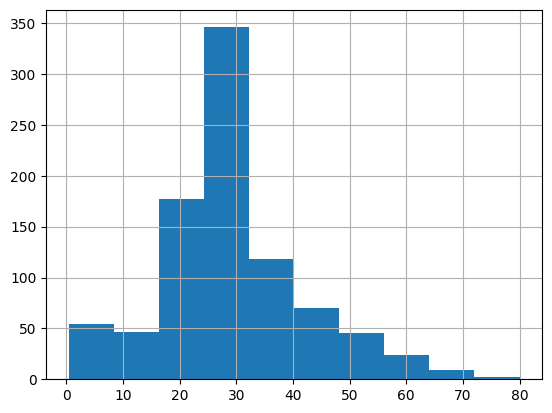

In [23]:
train_data['Age'].hist()

In [25]:
print(train_data['SibSp'].value_counts())
print(train_data['Parch'].value_counts())

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64
Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64


In [26]:
pd.crosstab(train_data['Embarked'], train_data['Survived'], normalize='index')

Survived,0,1
Embarked,,
0,0.000000,1.000000
1,0.617548,0.382452


In [27]:
train_data['FamilySize'] = train_data['SibSp'] + train_data['Parch'] + 1
test_data['FamilySize'] = test_data['SibSp'] + test_data['Parch'] + 1

train_data['IsAlone'] = (train_data['FamilySize'] == 1).astype(int)
test_data['IsAlone'] = (test_data['FamilySize'] == 1).astype(int)

In [28]:
train_data['Title'] = train_data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
test_data['Title'] = test_data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_12595/2092540548.py:1: SyntaxWarning: invalid escape sequence '\.'
  train_data['Title'] = train_data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
/tmp/ipykernel_12595/2092540548.py:2: SyntaxWarning: invalid escape sequence '\.'
  test_data['Title'] = test_data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [29]:
rare_titles = ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona']

train_data['Title'] = train_data['Title'].replace(rare_titles, 'Rare')
test_data['Title'] = test_data['Title'].replace(rare_titles, 'Rare')

In [30]:
train_data['AgeGroup'] = pd.cut(train['Age'], bins=[0,12,18,35,60,100], labels=False)
test_data['AgeGroup'] = pd.cut(test['Age'], bins=[0,12,18,35,60,100], labels=False)

In [31]:
train_data['Fare'] = np.log1p(train_data['Fare'])
test_data['Fare'] = np.log1p(test_data['Fare'])

In [32]:
drop_cols = ['Name', 'Ticket', 'PassengerId']

train_data.drop(columns=drop_cols, inplace=True)
test_ids = test['PassengerId']
test_data.drop(columns=drop_cols, inplace=True)

In [33]:
train_data = pd.get_dummies(train_data, drop_first=True)
test_data = pd.get_dummies(test_data, drop_first=True)

In [34]:
train_data, test_data = train_data.align(test_data, join='left', axis=1, fill_value=0)

In [36]:
X = train_data.drop('Survived', axis=1)
y = train_data['Survived']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

In [37]:
print(X_train.shape)
print(X_val.shape)

(712, 18)
(179, 18)


In [39]:
# LOGISTIC REGRESSION
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_val)

In [40]:
# RANDOM FOREST
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_val)

In [41]:
# XGBOOST
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_val)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:01:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [42]:
def evaluate_model(name, y_true, y_pred, model, X_val):
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, model.predict_proba(X_val)[:,1]))
    print(classification_report(y_true, y_pred))
    print("\n")

In [43]:
evaluate_model("Logistic Regression", y_val, y_pred_lr, lr, X_val)
evaluate_model("Random Forest", y_val, y_pred_rf, rf, X_val)
evaluate_model("XGBoost", y_val, y_pred_xgb, xgb, X_val)

--- Logistic Regression ---
Accuracy: 0.8268156424581006
ROC-AUC: 0.8666964741951967
              precision    recall  f1-score   support

           0       0.82      0.89      0.86       103
           1       0.84      0.74      0.78        76

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.82       179



--- Random Forest ---
Accuracy: 0.7877094972067039
ROC-AUC: 0.8622892181911088
              precision    recall  f1-score   support

           0       0.79      0.86      0.82       103
           1       0.79      0.68      0.73        76

    accuracy                           0.79       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.79      0.79      0.79       179



--- XGBoost ---
Accuracy: 0.8044692737430168
ROC-AUC: 0.87295605518651
              precision    recall  f1-score   support

           0       0.79      0.90      0.84       10

In [44]:
feature_importance = pd.Series(rf.feature_importances_, index=X_train.columns)
feature_importance.sort_values(ascending=False).head(10)

,0
Fare,0.247048
Age,0.197886
Sex_male,0.122769
Title_Mr,0.117553
Pclass,0.067126
FamilySize,0.045568
AgeGroup,0.040050
Cabin,0.032667
Title_Miss,0.032619
Title_Mrs,0.030147


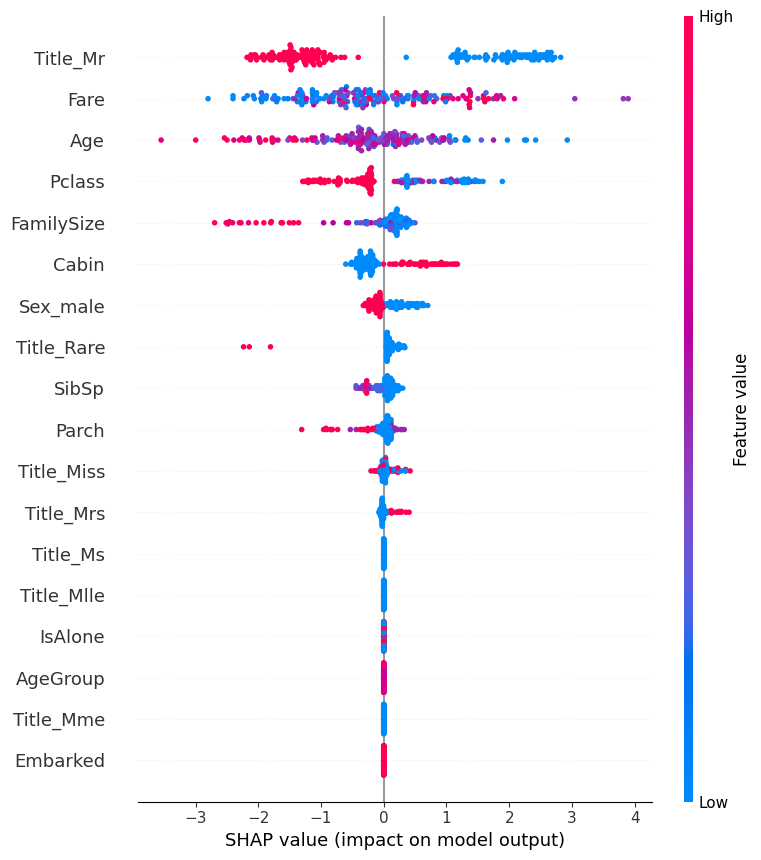

In [45]:
explainer = shap.Explainer(xgb)
shap_values = explainer(X_val)

shap.summary_plot(shap_values, X_val)

###
- **This project aimed to move beyond a basic classification task and build an interpretable machine learning system to predict passenger survival on the Titanic. Starting with raw data, an extensive exploratory data analysis (EDA) was conducted to understand underlying patterns. Key observations revealed that factors such as gender, passenger class, and age had a strong influence on survival, aligning with historical insights like “women and children first” and socioeconomic advantages.**

- **To enhance model performance, significant feature engineering was applied. New features such as FamilySize, IsAlone, and Title (extracted from passenger names) were created to capture social and relational dynamics. Additionally, transformations like log scaling of fare and handling missing values improved data quality. These engineered features proved critical in enabling even simple models to perform effectively.**

- **Multiple models—including Logistic Regression, Random Forest, and XGBoost—were trained and evaluated using metrics such as accuracy, precision, recall, and ROC-AUC. Interestingly, Logistic Regression outperformed more complex models, achieving an accuracy of ~82.6% and a strong ROC-AUC score. This indicated that the problem is largely linearly separable when meaningful features are used, highlighting the importance of feature engineering over model complexity.**

- **Further analysis showed that while models performed well in identifying non-survivors, predicting survivors remained more challenging, suggesting inherent dataset imbalance and more complex survival patterns. Feature importance analysis revealed that Fare, Age, Gender, Title, and Passenger Class were the most influential variables. These results reinforce the idea that survival was strongly tied to social status, economic class, and demographic factors.**

- **The project also emphasized model interpretability, demonstrating how predictions can be explained using feature contributions. This adds real-world value, as understanding why a model makes a decision is often as important as the prediction itself.**

- **Overall, this project highlights several key machine learning principles: the power of feature engineering, the effectiveness of simpler models on well-structured data, the importance of proper evaluation metrics, and the need for interpretability. Beyond just predicting survival, the model provides meaningful insights into the social and structural factors that influenced outcomes during the Titanic disaster, making it both a technically and contextually rich analysis.**